# Nathan 1


--- Initial Conditions ---
mass (oz)           : 5.125
circumference (inches): 9.125
x0 (ft)             : -1
y0 (ft)             : 60
z0 (ft)             : 6
v0 (mph)            : 95
theta (deg)         : -2
phi (deg)           : 179
wb (rpm)            : 1500
ws (rpm)            : 1000
wg (rpm)            : 0
tau (sec)           : 10000
dt (sec)            : 0.001
0                   : 0
T (deg F)           : 75
elev (ft)           : 0
vwind (mph)         : 0
phiwind (deg)       : 0
relative humidity (%): 50
barometric pressure (in Hg): 29.92
home plate crossing : 0
xf                  : 1.10692068060668
yf                  : 1.41666666666667
zf                  : 2.53263793517904
hangtime            : 0.442718875121589
vf                  : 86.2694012782501

Trajectory rows: 1127


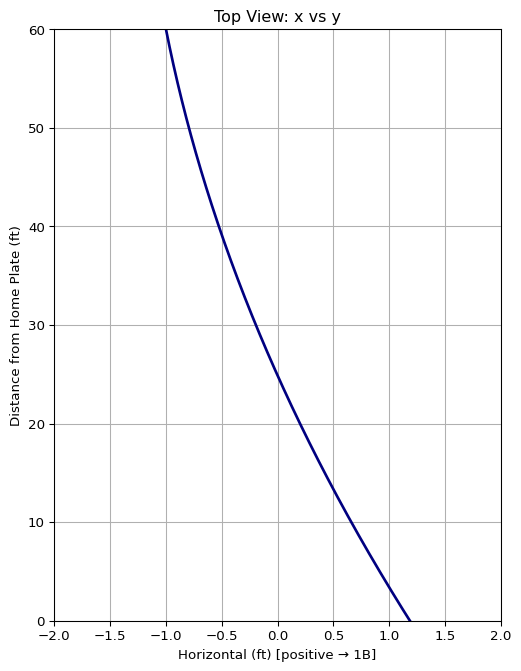

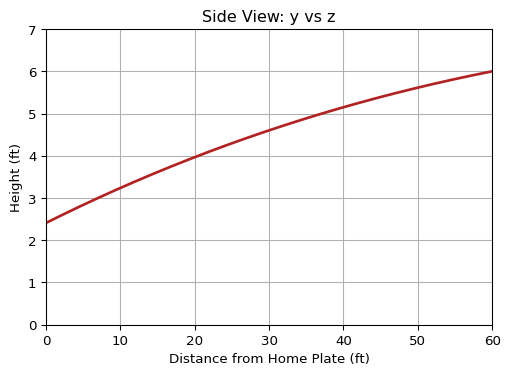

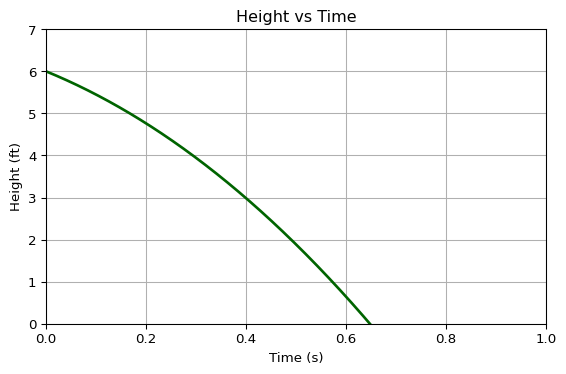

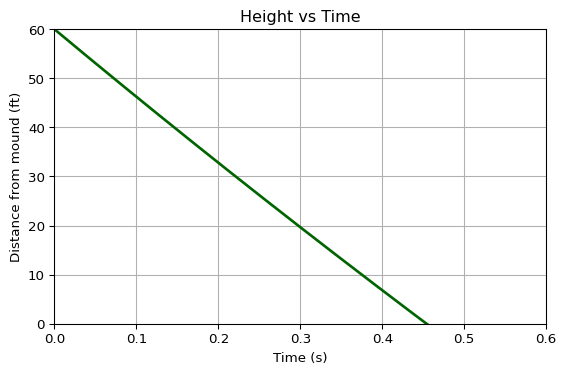

In [1]:
#!/usr/bin/env python3
"""
Reads Alan Nathan–style trajectory and initial-condition exports from Excel
and produces three diagnostic plots:
    1. Top view (x vs y)
    2. Side view (y vs z)
    3. Height vs time (z vs t)
"""

import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

# === Paths ===
base = Path("/Users/chipbrock/Dropbox/ImmediateWork/quarto_project_website/baseball")

traj_file = base / "trajectory.csv"
init_file = base / "init.json"

# === Load data ===
traj = pd.read_csv(traj_file)
with open(init_file) as f:
    init = json.load(f)

# === Print summary ===
print("\n--- Initial Conditions ---")
for k, v in init.items():
    print(f"{k:20s}: {v}")
print(f"\nTrajectory rows: {len(traj)}\n")

# === Convenience ===
t = traj["t"]
x = traj["x"]
y = traj["y"]
z = traj["z"]

# === 1. Top view (x vs y) ===
plt.figure(figsize=(6, 8))
plt.plot(x, y, color="navy", lw=2)
plt.gca().invert_yaxis()  # pitcher at top, home at bottom
plt.gca().invert_xaxis()  # positive x toward 1B side
plt.title("Top View: x vs y")
plt.xlabel("Horizontal (ft) [positive → 1B]")
plt.ylabel("Distance from Home Plate (ft)")
plt.grid(True)
plt.xlim(-2.0, 2.0)
plt.ylim(0.0, 60.0)
plt.show()        # ← show this figure now

# === 2. Side view (y vs z) ===
plt.figure(figsize=(6, 4))
plt.plot(y, z, color="firebrick", lw=2)
plt.gca().invert_xaxis()
plt.title("Side View: y vs z")
plt.xlabel("Distance from Home Plate (ft)")
plt.ylabel("Height (ft)")
plt.grid(True)
plt.xlim(0.0, 60.0)
plt.ylim(0.0, 7.0)
plt.show()        # ← show this figure now

# === 3. Height vs time (t vs z) ===
plt.figure(figsize=(6, 4))
plt.plot(t, z, color="darkgreen", lw=2)
plt.title("Height vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Height (ft)")
plt.grid(True)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 7.0)
plt.tight_layout()
plt.show()
plt.show()        # ← show this figure now

# === 3. Distance vs time (y vs t) ===
plt.figure(figsize=(6, 4))
plt.plot(t, y, color="darkgreen", lw=2)
plt.title("Height vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Distance from mound (ft)")
plt.grid(True)
plt.xlim(0.0, .60)
plt.ylim(0.0, 60.0)
plt.tight_layout()
plt.show()        # ← show this figure now